# A production data contract for Kaggle Polymarket L2

A public dataset is not a research input. It is a pile of files carrying
whatever timestamps, units and duplicate rows the recorder happened to
produce, under a license that may not permit what you want to do.

A data contract is the layer between the two. It states what the tables
guarantee, checks each guarantee rather than assuming it, and records
exactly which bytes it read. Without one, an unreproducible result is
indistinguishable from a wrong one.

This recipe turns a bounded slice of the
[Marvingozo Polymarket dataset](https://www.kaggle.com/datasets/marvingozo/polymarket-tick-level-orderbook-dataset)
into canonical, versioned h5i-db tables. The objective is not an
alpha claim. It is the evidence layer a credible backtest needs:

- exact source-file hashes and license;
- explicit timestamp repair;
- atomic full-book events;
- one normalized YES contract;
- a named h5i-db snapshot before any strategy is created.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| data contract    | the stated guarantees about what a table holds, checked rather than assumed |
| L2               | several order book price levels per side, with the size resting at each |
| book event       | one atomic update to the order book, applied in full or not at all |
| timestamp repair | correcting times that arrive in the wrong unit, order, or zone |
| source hash      | the checksum of each input file, recorded so the ingest is traceable |
| YES contract     | the binary contract that pays 1.00 if the event happens and 0.00 if it does not |
| snapshot         | a named, checksummed pin of table versions, taken before any strategy exists |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

## Download only what the recipe uses

The four files total roughly 165 MB compressed. We intentionally do not
download a 1–2 GB daily tick file. Run the printed commands from the
repository root if the cache is empty. Kaggle authentication is required.

The dataset is **CC BY-NC 4.0**: this recipe and its derived work are for
non-commercial/academic use unless you obtain separate rights.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
import cookbook_utils as cu

CACHE = Path("data/cache/kaggle-polymarket")
missing = cu.kaggle_missing_files(CACHE)
if missing:
    commands = cu.kaggle_download_commands(CACHE)
    raise FileNotFoundError("Run these bounded downloads:\n" + "\n".join(commands))
print(f"dataset={cu.KAGGLE_POLYMARKET_DATASET}")
print(f"license={cu.KAGGLE_POLYMARKET_LICENSE}")

dataset=marvingozo/polymarket-tick-level-orderbook-dataset
license=CC BY-NC 4.0


Hashing the inputs is part of reproducibility. A Kaggle slug and filename
are not immutable identifiers; a publisher can replace a file in a new
dataset version.

In [2]:
manifest = cu.kaggle_source_manifest(CACHE)
manifest.to_pandas()[["remote_path", "bytes", "sha256", "license"]]

,remote_path,bytes,sha256,license
0,features/ml_features_1m_v2.parquet,32260516,2d0a18fea3a6de1d3fda02c21eec4d1a1ee77dfe900445...,CC BY-NC 4.0
1,labels/market_targets.parquet,15356673,901fb2fcb1a69dbf1e898d032e58b21d2f1147ee22ea1b...,CC BY-NC 4.0
2,labels/trades.parquet,34051625,244a33af8615f43690fa8def1efa41b300be0edb2f080f...,CC BY-NC 4.0
3,snapshots/snapshots_2026-03-09.parquet,84170155,806d49605b59334aebad7770a7c8e4bc5a51e36c8b7e94...,CC BY-NC 4.0


## Predicate-push down before materialising

The loader lazily intersects one day of snapshots, feature bars, trades,
and closed-market labels. It selects the overlapping market with the most
prints, then reads only that market. Ten levels per side are retained.

The current feature artifact spans March 6–11 even though the dataset
README describes 21-day coverage. The loader therefore verifies overlap
from Parquet metadata and values instead of trusting the prose.

In [3]:
sample = cu.load_kaggle_sample(CACHE, depth_levels=10)
print(sample.question)
print(f"market={sample.market_id}")
print(f"eventual resolution target={sample.target} (audit only, never a feature)")
pd.Series(sample.audit, name="value").to_frame()

Will global temperature increase by between 1.10ºC and 1.14ºC in February 2026?
market=0x7d4e693277c1d7990a5227146ee70f56750c73be6f9d129e8558be936848dc85
eventual resolution target=0 (audit only, never a feature)


,value
dataset,marvingozo/polymarket-tick-level-orderbook-dat...
license,CC BY-NC 4.0
sample_date,2026-03-09
source_snapshot_rows,227
source_feature_rows,1390
source_trade_rows,198
canonical_book_rows,4540
canonical_trade_rows,198
depth_levels,10
trade_aggressor_known,False


## Validate the causal and book contracts

`timestamp_created_at` is later than `timestamp_received` in this snapshot
file, so the two source clocks cannot be interpreted literally as event and
arrival time. The loader preserves event time and conservatively sets
`ts_init = max(created, received)`. Every correction is counted.

The dataset's bundled `target` column is deliberately removed from the
feature table. Keeping it would leak the eventual market resolution into
every training row.

In [4]:
book = sample.book_deltas.to_pandas()
features = sample.features.to_pandas()

assert "target" not in features.columns
assert (book["ts_init"] >= book["ts_event"]).all()
assert sample.audit["crossed_snapshots_dropped"] == 0
assert book.groupby("event_index")["is_last"].sum().eq(1).all()
assert book["price"].between(0.0, 1.0, inclusive="both").all()
assert (book["size"] > 0).all()
print(
    f"{book['event_index'].nunique():,} atomic snapshots, "
    f"{len(book):,} canonical levels, "
    f"{sample.audit['clock_adjustments']:,} clock repairs"
)

227 atomic snapshots, 4,540 canonical levels, 227 clock repairs


A top-of-book chart is a fast visual contract test. Crosses, inverted
sides, or discontinuous timestamps are much easier to spot here than in a
strategy tearsheet.

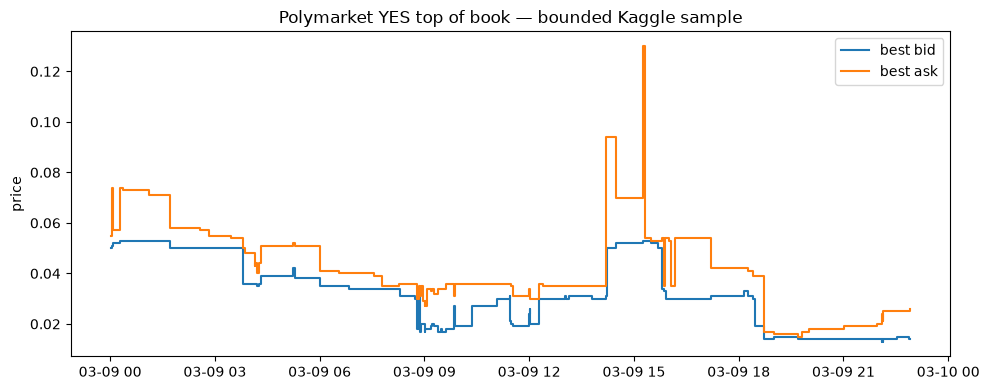

In [5]:
bids = (
    book[book["side"] == "buy"]
    .groupby(["event_index", "ts_init"], as_index=False)["price"]
    .max()
    .rename(columns={"price": "bid"})
)
asks = (
    book[book["side"] == "sell"]
    .groupby(["event_index", "ts_init"], as_index=False)["price"]
    .min()
    .rename(columns={"price": "ask"})
)
tops = bids.merge(asks, on=["event_index", "ts_init"], validate="one_to_one")
assert (tops["bid"] < tops["ask"]).all()

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(tops["ts_init"], tops["bid"], where="post", label="best bid")
ax.step(tops["ts_init"], tops["ask"], where="post", label="best ask")
ax.set(title="Polymarket YES top of book — bounded Kaggle sample", ylabel="price")
ax.legend()
fig.tight_layout()

## Commit the approved research cut

Raw Parquets remain disposable cache files. Canonical tables and the
external-byte manifest become versioned h5i-db inputs. The resolution label
is not ingested into the strategy feature table.

In [6]:
db = h5i_db.Database(cu.fresh_db("04_kaggle_polymarket_contract"), create=True)
tables = {
    "instruments": (sample.instruments, "ts_init"),
    "book_deltas": (sample.book_deltas, "ts_init"),
    "trades": (sample.trades, "ts_init"),
    "features_1m": (sample.features, "ts_init"),
}
for name, (table, time_column) in tables.items():
    db.create_table(name, table.schema, time_column=time_column)
    db.append(name, table, note="bounded CC BY-NC Kaggle Polymarket sample")

db.snapshot(
    "kaggle-polymarket-2026-03-09",
    tables=list(tables),
    note="Validated one-market research cut; source hashes recorded above",
)
db.tables()

['book_deltas', 'features_1m', 'instruments', 'trades']

## What this cut can and cannot prove

These full snapshots are suitable for conservative snapshot replay and
spread/depth studies. They are not the tick-by-tick delta stream, so they
cannot reveal every queue transition between snapshots. Do not call a
queue-position result from this sample “exact.”

For exact queue replay, apply the same contract to one daily
`orderbook_YYYY-MM-DD.parquet` file with a lazy `market_id` filter. Never
call `read_parquet` on the whole daily file: the publisher estimates roughly
300 million rows and 50 GB of RAM per day.

In [7]:
db.close()